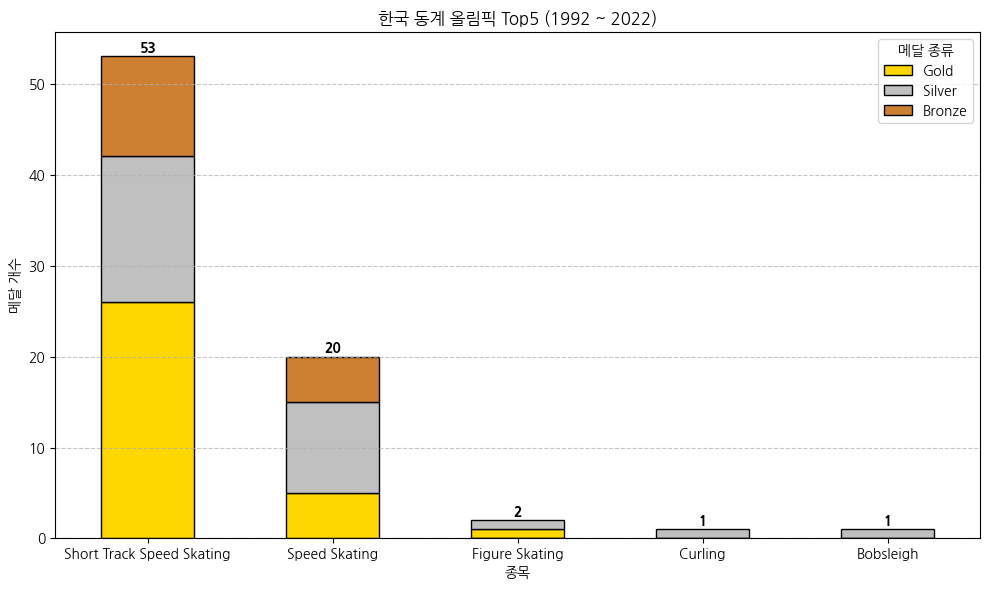

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

df = pd.read_csv('Olympic_Athlete_Event_Results.csv')

# 한국 동계 올림픽 데이터 필터링
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 메달 획득 데이터만 추출 및 단체전 중복 제거
# 한 경기에 여러 선수가 있어도 메달은 1개로 집계
korea_medals = winter_korea[winter_korea['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])

# 종목별(sport)로 메달 종류(medal) 개수 집계
medal_counts = korea_medals.groupby(['sport', 'medal']).size().unstack(fill_value=0)

# 금, 은, 동 순서 정렬 및 상위 5개 종목 선정 (합계 기준)
medal_counts['total'] = medal_counts.sum(axis=1)
top5_sports = medal_counts.sort_values(by='total', ascending=False).head(5)

# 금, 은, 동 순서로 컬럼 정렬
plot_data = top5_sports[['Gold', 'Silver', 'Bronze']]

# 누적 막대 그래프 그리기
ax = plot_data.plot(kind='bar', stacked=True, color=['#FFD700', '#C0C0C0', '#CD7F32'], figsize=(10, 6), edgecolor='black')

plt.title('한국 동계 올림픽 Top5 (1992 ~ 2022)')
plt.xlabel('종목')
plt.ylabel('메달 개수')
plt.xticks(rotation=0)
plt.legend(title='메달 종류')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 총 합계 숫자 표시
for i, total in enumerate(top5_sports['total']):
    ax.text(i, total + 0.5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_6064\3600984042.py:12: SyntaxWarning: invalid escape sequence '\d'
  korea_medals_clean['Year'] = korea_medals_clean['edition'].str.extract('(\d+)').astype(int)


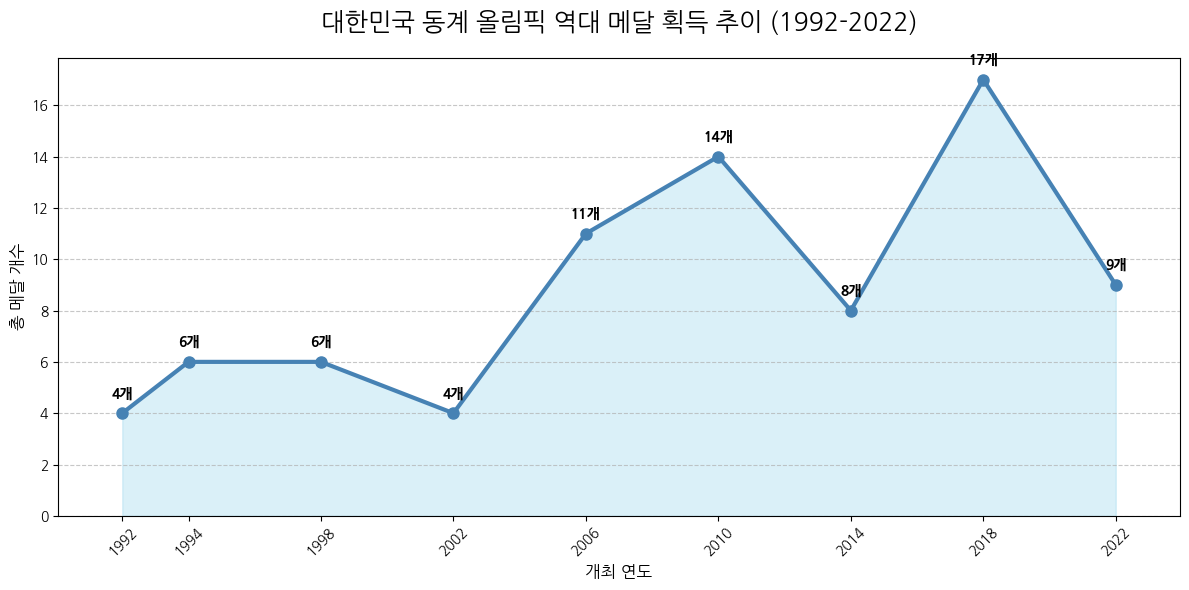

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

df = pd.read_csv('Olympic_Athlete_Event_Results.csv')
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 메달 중복 제거 (단체전 고려: 동일 대회, 종목, 세부이벤트의 메달은 1개로 집계)
korea_medals_clean = winter_korea[winter_korea['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])

# 연도별 매달 개수
korea_medals_clean['Year'] = korea_medals_clean['edition'].str.extract('(\d+)').astype(int)
yearly_medals = korea_medals_clean.groupby('Year').size().reset_index(name='Medal_Count')

plt.figure(figsize=(12, 6))

# 막대 그래프와 꺾은선 그래프를 혼합
plt.bar(yearly_medals['Year'], yearly_medals['Year'].map(lambda x: 0), alpha=0)
plt.plot(yearly_medals['Year'], yearly_medals['Year'].map(lambda x: 0), alpha=0) 

plt.fill_between(yearly_medals['Year'], yearly_medals['Medal_Count'], color="skyblue", alpha=0.3)
plt.plot(yearly_medals['Year'], yearly_medals['Medal_Count'], color="steelblue", marker='o', linewidth=3, markersize=8)

for i in range(len(yearly_medals)):
    plt.text(yearly_medals['Year'][i], yearly_medals['Medal_Count'][i] + 0.5, f"{yearly_medals['Medal_Count'][i]}개", ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title('대한민국 동계 올림픽 역대 메달 획득 추이 (1992-2022)', fontsize=18, pad=20)
plt.xlabel('개최 연도', fontsize=12)
plt.ylabel('총 메달 개수', fontsize=12)
plt.xticks(yearly_medals['Year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_6064\3047984916.py:11: SyntaxWarning: invalid escape sequence '\d'
  korea_medals['Year'] = korea_medals['edition'].str.extract('(\d+)').astype(int)


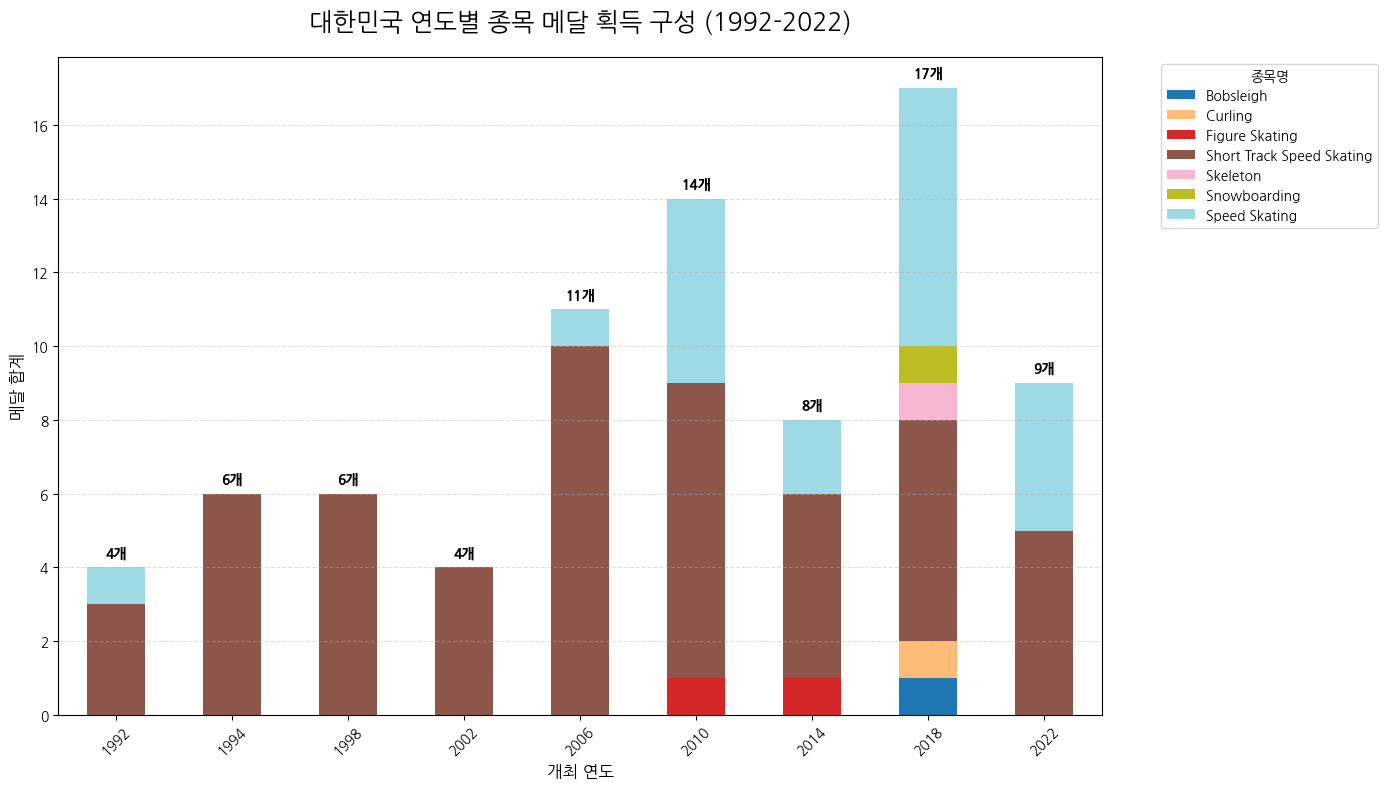

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

df = pd.read_csv('Olympic_Athlete_Event_Results.csv')
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 메달 중복 제거 및 연도 추출
korea_medals = winter_korea[winter_korea['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])
korea_medals['Year'] = korea_medals['edition'].str.extract('(\d+)').astype(int)

# 데이터 재구조화 (Pivot)
pivot_df = korea_medals.groupby(['Year', 'sport']).size().unstack(fill_value=0)

ax = pivot_df.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')

plt.title('대한민국 연도별 종목 메달 획득 구성 (1992-2022)', fontsize=18, pad=20)
plt.xlabel('개최 연도', fontsize=12)
plt.ylabel('메달 합계', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='종목명', bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 밖으로 이동
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, total in enumerate(pivot_df.sum(axis=1)):
    plt.text(i, total + 0.3, f'{int(total)}개', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()